#### Import Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

import warnings
warnings.filterwarnings('ignore')

import time

#### Import Datasets

In [49]:
%store -r Set1_X_Train_scaled
%store -r Set1_X_Test_scaled
%store -r Set1_y_Train
%store -r Set1_y_Test
%store -r Set1_X_Train_scaled_2
%store -r Set1_X_Test_scaled_2

In [50]:
max_value = Set1_y_Test.max()
min_value = Set1_y_Test.min()

print("Maximum value:", max_value)
print("Minimum value:", min_value)

Maximum value: RUL    145
dtype: int64
Minimum value: RUL    7
dtype: int64


#### Support Vector Machine

In [51]:
'''
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}

svr = SVR()

grid_search = GridSearchCV(svr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(Set1_X_Train_scaled, Set1_y_Train)

best_kernel = grid_search.best_params_['kernel']
best_C = grid_search.best_params_['C']
best_gamma = grid_search.best_params_['gamma']
best_score = -grid_search.best_score_  

print("Best Kernel:", best_kernel)
print("Best C:", best_C)
print("Best gamma:", best_gamma)
print("Best Score (MSE):", best_score)

mean_test_scores = grid_search.cv_results_['mean_test_score']
params = grid_search.cv_results_['params']

for param, score in zip(params, mean_test_scores):
    print(f"Kernel: {param['kernel']}, C: {param['C']}, Gamma: {param['gamma']}, Mean Test MSE: {-score}")
'''

'\nparam_grid = {\n    \'kernel\': [\'linear\', \'poly\', \'rbf\', \'sigmoid\'],\n    \'C\': [0.001, 0.01, 0.1, 1, 10, 100],\n    \'gamma\': [0.001, 0.01, 0.1, 1, 10]\n}\n\nsvr = SVR()\n\ngrid_search = GridSearchCV(svr, param_grid=param_grid, cv=5, scoring=\'neg_mean_squared_error\', verbose=1)\ngrid_search.fit(Set1_X_Train_scaled, Set1_y_Train)\n\nbest_kernel = grid_search.best_params_[\'kernel\']\nbest_C = grid_search.best_params_[\'C\']\nbest_gamma = grid_search.best_params_[\'gamma\']\nbest_score = -grid_search.best_score_  \n\nprint("Best Kernel:", best_kernel)\nprint("Best C:", best_C)\nprint("Best gamma:", best_gamma)\nprint("Best Score (MSE):", best_score)\n\nmean_test_scores = grid_search.cv_results_[\'mean_test_score\']\nparams = grid_search.cv_results_[\'params\']\n\nfor param, score in zip(params, mean_test_scores):\n    print(f"Kernel: {param[\'kernel\']}, C: {param[\'C\']}, Gamma: {param[\'gamma\']}, Mean Test MSE: {-score}")\n'

In [52]:
start = time.time()

svm_reg = SVR(kernel="rbf", C=100, gamma=0.5, epsilon=0.01)

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

svm_reg.fit(Set1_X_Train_scaled, Set1_y_Train_array)
end_train = time.time()

start_predict = time.time()
svm_reg_pred_train = svm_reg.predict(Set1_X_Train_scaled)
end_predict = time.time()
svm_reg_pred_test = svm_reg.predict(Set1_X_Test_scaled)
end_predict_test = time.time()

svm_reg_pred_test_int = svm_reg_pred_test.astype(int)
svm_reg_pred_train_int = svm_reg_pred_train.astype(int)

#### Support Vector Machine Evaluation 

In [53]:
# Mean Squared Error
mse_train_svm = mean_squared_error(Set1_y_Train_array, svm_reg_pred_train_int)
mse_test_svm = mean_squared_error(Set1_y_Test_array, svm_reg_pred_test_int)

# Root Mean Squared Error
rmse_train_svm = np.sqrt(mse_train_svm)
rmse_test_svm = np.sqrt(mse_test_svm)

# Mean Absolute Error
mae_train_svm = mean_absolute_error(Set1_y_Train_array, svm_reg_pred_train_int)
mae_test_svm = mean_absolute_error(Set1_y_Test_array, svm_reg_pred_test_int)

# R2 Score
r2_train_svm = r2_score(Set1_y_Train_array, svm_reg_pred_train_int)
r2_test_svm = r2_score(Set1_y_Test_array, svm_reg_pred_test_int)

# Time
fit_time = end_train - start
predict_time_train = end_predict - start_predict
predict_time_test = end_predict_test - end_predict
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_svm)
print("Root Mean Squared Error:", rmse_train_svm)
print("Mean Absolute Error:", mae_train_svm)
print("R-squared Score:", r2_train_svm)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_svm)
print("Root Mean Squared Error:", rmse_test_svm)
print("Mean Absolute Error:", mae_test_svm)
print("R-squared Score:", r2_test_svm)

# Time
print("\n--Fit, Training Times--")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(predict_time_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(predict_time_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 1770.6238669962677
Root Mean Squared Error: 42.078781671957515
Mean Absolute Error: 29.124957588095583
R-squared Score: 0.626794013150574

--Testing Set Evaluation--
Mean Squared Error: 1030.73
Root Mean Squared Error: 32.10498403675043
Mean Absolute Error: 24.87
R-squared Score: 0.4031222739690361

--Fit, Training Times--
Time to fit: 13.66 seconds
Time to predict (train set): 17.39 seconds
Time to predict (test set): 0.08 seconds
Total Time: 31.13 seconds


#### Plot Evaluation Results

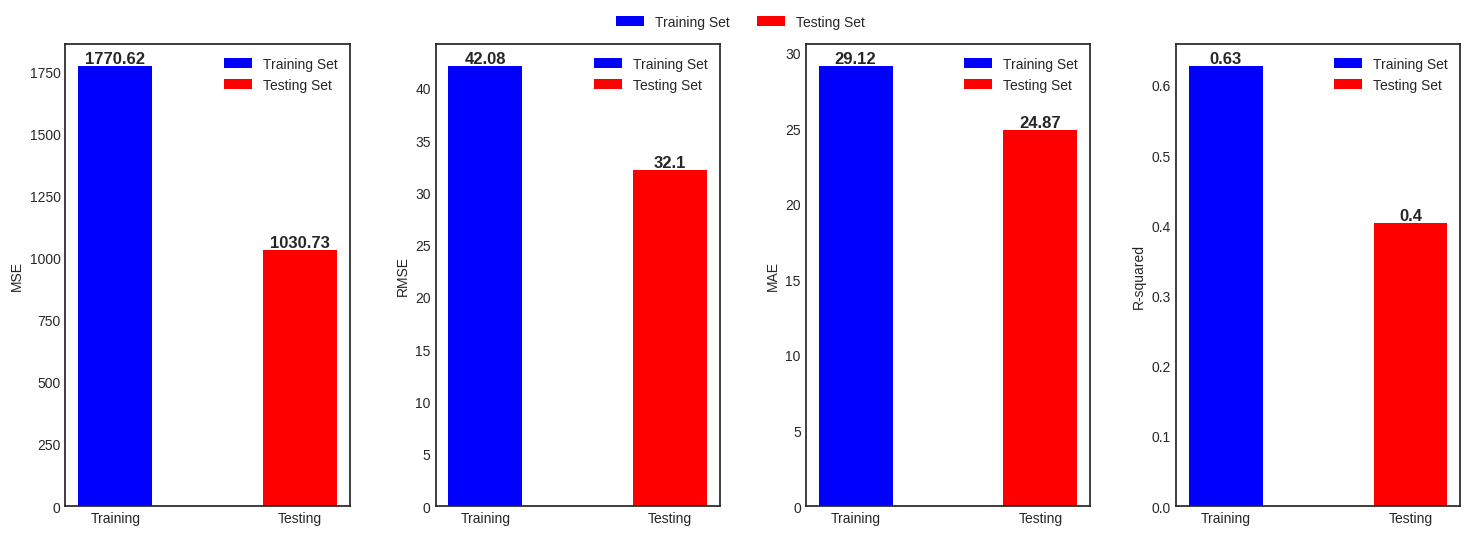

In [54]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared']
train_metrics = [mse_train_svm, rmse_train_svm, mae_train_svm, r2_train_svm]
test_metrics = [mse_test_svm, rmse_test_svm, mae_test_svm, r2_test_svm]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Actual vs Predicted Values

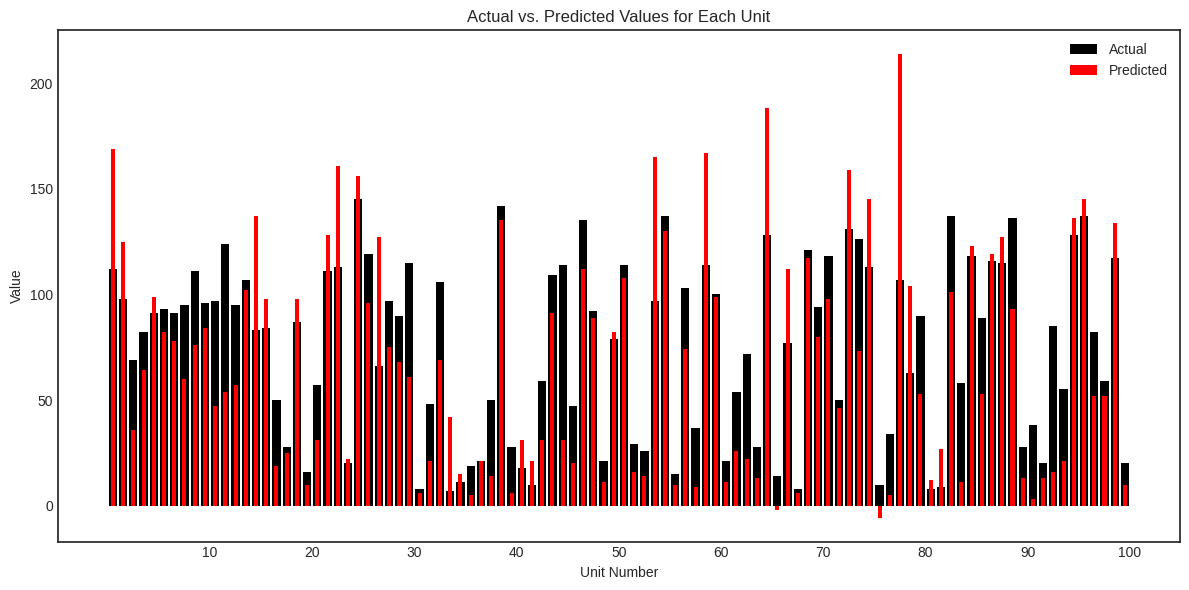

In [55]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(svm_reg_pred_test_int)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

#### Support Vector Machine (Dropped Constant, Highly Related Features, Applied Upper RUL Limit)

##### Import Dataset

In [56]:
%store -r FD1_X_Train_sc
%store -r FD1_X_Test_sc
%store -r FD1_y_Train
%store -r FD1_y_Test

#### SVM Regressor

In [57]:
start = time.time()
svm_reg_new = SVR(kernel='sigmoid', C=10, gamma=0.01, epsilon=0.01)

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

svm_reg_new.fit(FD1_X_Train_sc, FD1_y_Train_array)
end_train = time.time()

start_predict = time.time()
svm_reg_pred_train_new = svm_reg_new.predict(FD1_X_Train_sc)
end_predict = time.time()

svm_reg_pred_test_new = svm_reg_new.predict(FD1_X_Test_sc)
end_predict_test = time.time()

clipped_train_new = np.clip(svm_reg_pred_train_new, 7, 145)
clipped_test_new = np.clip(svm_reg_pred_test_new, 7, 145)

#### Support Vector Machine Evaluation

In [58]:
# Mean Squared Error
mse_train_svm_new = mean_squared_error(FD1_y_Train_array, clipped_train_new)
mse_test_svm_new = mean_squared_error(FD1_y_Test_array, clipped_test_new)

# Root Mean Squared Error
rmse_train_svm_new = np.sqrt(mse_train_svm_new)
rmse_test_svm_new = np.sqrt(mse_test_svm_new)

# Mean Absolute Error
mae_train_svm_new = mean_absolute_error(FD1_y_Train_array, clipped_train_new)
mae_test_svm_new = mean_absolute_error(FD1_y_Test_array, clipped_test_new)

# R2 Score
r2_train_svm_new = r2_score(FD1_y_Train_array, clipped_train_new)
r2_test_svm_new = r2_score(FD1_y_Test_array, clipped_test_new)

# Time
fit_time = end_train - start
predict_time_train = end_predict - end_train
predict_time_test = end_predict_test - end_predict
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_svm_new)
print("Root Mean Squared Error:", rmse_train_svm_new)
print("Mean Absolute Error:", mae_train_svm_new)
print("R-squared Score:", r2_train_svm_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_svm_new)
print("Root Mean Squared Error:", rmse_test_svm_new)
print("Mean Absolute Error:", mae_test_svm_new)
print("R-squared Score:", r2_test_svm_new)

# Time
print("\n--Fit, Training Times--")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(predict_time_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(predict_time_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 453.5238687436139
Root Mean Squared Error: 21.2960998481791
Mean Absolute Error: 17.2403277967001
R-squared Score: 0.7596971855417111

--Testing Set Evaluation--
Mean Squared Error: 559.3874141895375
Root Mean Squared Error: 23.651372353196283
Mean Absolute Error: 17.29770855134502
R-squared Score: 0.6760685264309838

--Fit, Training Times--
Time to fit: 14.54 seconds
Time to predict (train set): 12.13 seconds
Time to predict (test set): 0.06 seconds
Total Time: 26.73 seconds


#### Plot Evaluation Results

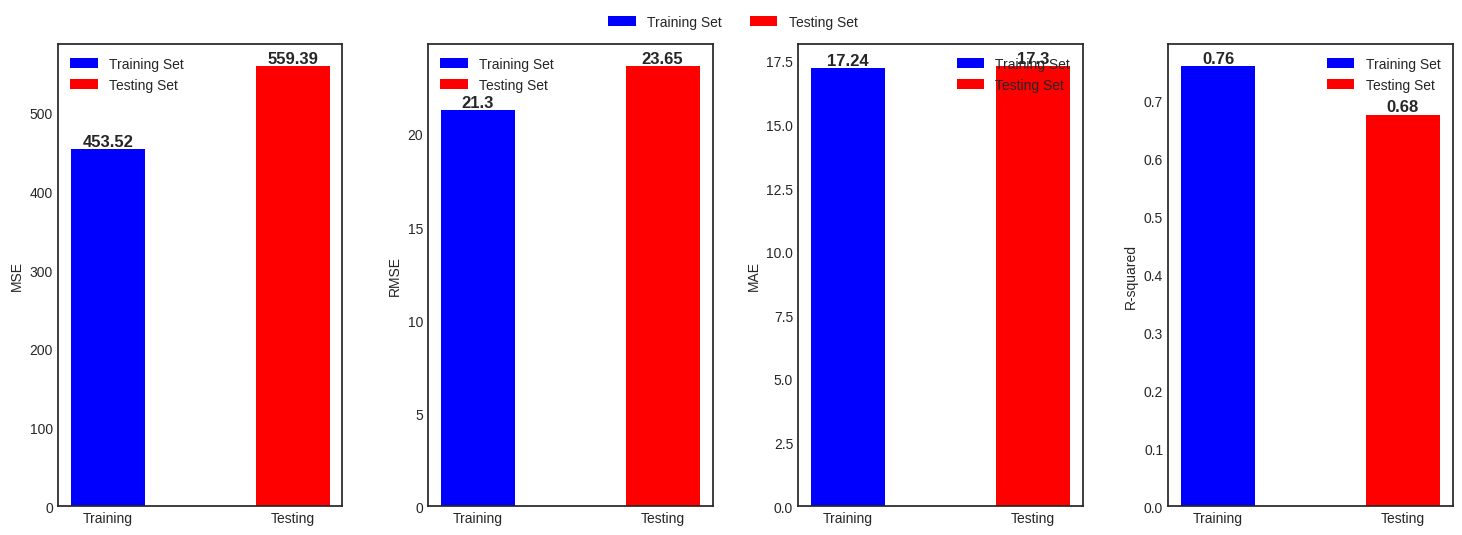

In [59]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared']
train_metrics_2 = [mse_train_svm_new, rmse_train_svm_new, mae_train_svm_new, r2_train_svm_new]
test_metrics_2 = [mse_test_svm_new, rmse_test_svm_new, mae_test_svm_new, r2_test_svm_new]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics_2, test_metrics_2)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

#### Plot Predicted vs Actual Values

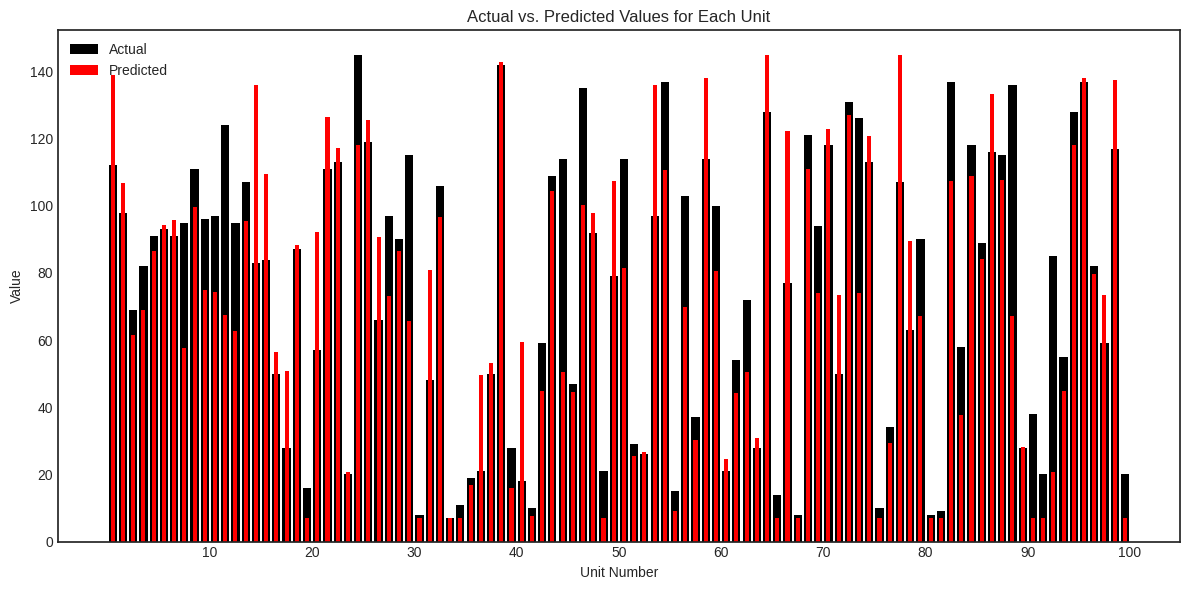

In [60]:
num_units = len(FD1_y_Test_array)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(FD1_y_Test_array)
predicted_values = np.squeeze(clipped_test_new)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

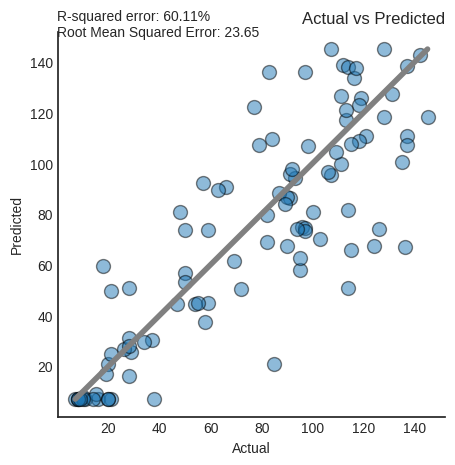

In [61]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=5,5 

fig,ax = plt.subplots()
plt.title('Actual vs Predicted', loc='right')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=FD1_y_Test_array,
                y=clipped_test_new,
                s=100,
                alpha=0.5,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             y=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             linewidth=4,
             color='gray',
             ax=ax)

plt.annotate(text=('R-squared error: '+ "{:.2%}".format(svm_reg_new.score(FD1_X_Test_sc, FD1_y_Test_array)) +'\n' +
                  'Root Mean Squared Error: '+ "{:.2f}".format(mean_squared_error(FD1_y_Test_array, clipped_test_new, squared=False))),
             xy=(0,150),
             size='medium')

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()